In [328]:
import os
import numpy as np
import pandas as pd
import joblib
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import m2cgen as m2c
import itertools
import re
import json
import matplotlib.pyplot as plt

def load_and_merge_files(file_paths, encoding="1251", sep=";"):
    """
    Читает файлы по списку путей и склеивает их в один DataFrame.
    """
    all_dfs = []
    
    for path in file_paths:
        print(f"Загрузка: {path}")
        # Читаем файл
        df = pd.read_csv(path, encoding=encoding, sep=sep)
        
        # ОЧЕНЬ ВАЖНО: очищаем названия колонок от пробелов сразу при загрузке
        df.columns = df.columns.str.strip()
        
        all_dfs.append(df)
    
    # Склеиваем всё вместе
    merged_df = pd.concat(all_dfs, axis=0, ignore_index=True, sort=False)
    
    print(f"Итоговый размер объединенного датасета: {merged_df.shape}")
    return merged_df

# Пример использования:
files = ["data/1.csv", "data/2.csv", "data/4.csv", "data/5.csv"]
df_train = load_and_merge_files(files)
df_train.columns = df_train.columns.str.strip()
print(df_train.columns)

df_val = pd.read_csv("data/example.csv", encoding="utf-8")
df_val.columns = df_val.columns.str.strip()
labels_true_val = df_val.pop("0 - Bad, 1 - Good")


# ==========================================
# 1. ОТНОСИТЕЛЬНЫЕ ПРИЗНАКИ (Исправленные)
# ==========================================
def extract_features(signal, window_size=15):
    """
    Вычисляет ОТНОСИТЕЛЬНЫЕ признаки.
    Смотрит на diff (разницу с предыдущей точкой) - это лучший маркер для скачков.
    """
    diff = signal.diff().abs().fillna(0)
    rolling_median = signal.rolling(window=window_size, min_periods=1).median().fillna(0)
    rolling_std = signal.rolling(window=window_size, min_periods=1).std().fillna(0)
    
    # Стабилизатор 0.1 - сглаживает микро-дребезг и защищает от деления на ноль
    base_level = np.abs(rolling_median) + 0.1 
    
    rel_diff = diff / base_level
    rel_std = rolling_std / base_level
    
    features = pd.DataFrame({
        'rel_diff': rel_diff,
        'rel_std': rel_std
    })
    
    return features.bfill()

Загрузка: data/1.csv
Загрузка: data/2.csv
Загрузка: data/4.csv
Загрузка: data/5.csv
Итоговый размер объединенного датасета: (78211, 70)
Index(['TimeStamp', 'Температура масла в магистрали общей откачки (поз. Тм)',
       'Температура слива масла из опоры турбины (поз. Т606)',
       'Температура масла на входе в двигатель за фильтром (поз. Т607)',
       'Температура топливного газа перед СК (перед расходомерным устройством) (поз. Ттг)',
       'Давление масла в нагнетающей магистрали двигателя (после фильтра) (поз. Pм)',
       'Давление масла в магистрали общей откачки (поз. Р615)',
       'Давление за ОК Pk1', 'Давление за ОК Pk2',
       'Давление топливного газа перед дозаторами (поз. Pтг1.1)',
       'Вибрация промежуточного корпуса газогенератора (гориз.) (поз. В1)',
       'Вибрация корпуса силовой турбины (гориз.) (поз. В2)',
       'Положение дозатора газа 8402 (или ДУС-6,5 МП) ( поз. А ДГ)',
       'Контроль управления дозатором газа ДГ',
       'Частота вращения РНД (Расчет

In [329]:
def compute_metrics(labels_true, labels_pred, dp=4) -> dict:
    metrics = dict()
    metrics["accuracy"] = round(accuracy_score(labels_true, labels_pred), dp)
    metrics["precision"] = round(precision_score(labels_true, labels_pred, pos_label=0, zero_division=0), dp)
    metrics["recall"] = round(recall_score(labels_true, labels_pred, pos_label=0, zero_division=0), dp)
    metrics["f1"] = round(f1_score(labels_true, labels_pred, pos_label=0, zero_division=0), dp)

    return metrics

In [330]:
def _train_model(df_train, window_size, percentile_diff, threshold, max_depth, time_column='TimeStamp',) -> DecisionTreeClassifier:
    all_real_features = []
    for col in[c for c in df_train.columns if c != time_column]:
        feats = extract_features(df_train[col], window_size)
        all_real_features.append(feats.values)
    X_real = np.vstack(all_real_features)
    
    p_diff = np.percentile(X_real[:, 0], percentile_diff)
    p_std = np.percentile(X_real[:, 1], percentile_diff)
    
    threshold_diff = max(p_diff * 5, threshold)
    threshold_std = max(p_std * 5, threshold)
    
    mask_clean = (X_real[:, 0] < threshold_diff) & (X_real[:, 1] < threshold_std)
    X_normal = X_real[mask_clean]
    y_normal = np.ones(len(X_normal))
    
    n_anomalies = int(len(X_normal) * 0.1)
    
    X_anom_diff = np.column_stack((
        np.random.uniform(threshold_diff * 1.1, threshold_diff * 10, n_anomalies),
        np.random.uniform(0, p_std, n_anomalies)
    ))
    X_anom_std = np.column_stack((
        np.random.uniform(0, p_diff, n_anomalies),
        np.random.uniform(threshold_std * 1.1, threshold_std * 10, n_anomalies)
    ))
    X_anom_both = np.column_stack((
        np.random.uniform(threshold_diff * 1.1, threshold_diff * 10, n_anomalies),
        np.random.uniform(threshold_std * 1.1, threshold_std * 10, n_anomalies)
    ))
    
    X_anomalous = np.vstack((X_anom_diff, X_anom_std, X_anom_both))
    y_anomalous = np.zeros(len(X_anomalous))
    
    X_train = np.vstack((X_normal, X_anomalous))
    y_train = np.concatenate((y_normal, y_anomalous))
    
    model = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    model.fit(X_train, y_train)

    return model
    

In [331]:
def tune_hyperparameters(df_train, df_val, labels_true_val, val_sensor_col, param_grid, target_metric='f1'):
    """
    Перебирает сетку гиперпараметров и находит лучшую модель.
    
    val_sensor_col - название колонки в df_val, для которой у нас есть labels_true 
                      (например, "Тм на входе в Д").
    target_metric - 'f1', 'recall', 'precision' или 'accuracy'.
    """
    # Распаковываем сетку параметров во все возможные комбинации
    keys = param_grid.keys()
    values = (param_grid[key] for key in keys)
    combinations =[dict(zip(keys, combination)) for combination in itertools.product(*values)]
    
    print(f"Подбор гиперпараметров. Всего комбинаций: {len(combinations)}\n")
    
    best_params = None
    best_score = -1.0
    best_metrics = None
    results_history =[]

    for i, params in enumerate(combinations):
        print(f"[{i+1}/{len(combinations)}] ...")
        w_size = params['window_size']
        p_diff = params['percentile_diff']
        thresh = params['threshold']
        m_depth = params['max_depth']
        
        # --- 1. ОБУЧЕНИЕ (в памяти, без сохранения файлов) ---
        model = _train_model(df_train=df_train, window_size=w_size, percentile_diff=p_diff, threshold=thresh, max_depth=m_depth)
        
        # --- 2. ИНФЕРЕНС НА ТЕСТЕ ---
        # ВАЖНО: Тестовые признаки извлекаем с ТЕМ ЖЕ window_size
        test_signal = df_val[val_sensor_col]
        test_features = extract_features(test_signal, w_size)
        X_test = test_features.values
        
        labels_pred = model.predict(X_test).astype(int)
        
        # --- 3. РАСЧЕТ МЕТРИК ---
        metrics = compute_metrics(labels_true_val, labels_pred)
        current_score = metrics[target_metric]
        
        # Сохраняем в историю
        trial_result = {**params, **metrics}
        results_history.append(trial_result)
        
        if current_score > best_score:
            best_score = current_score
            best_params = params
            best_metrics = metrics
            
        # Раскомментируйте строку ниже, если хотите видеть лог каждого шага
        # print(f"[{i+1}/{len(combinations)}] {target_metric}={current_score:.4f} | {params}")

    print("="*60)
    print(f"🏆 ЛУЧШИЕ ПАРАМЕТРЫ ПО МЕТРИКЕ '{target_metric.upper()}':")
    print(f"Параметры: {best_params}")
    print(f"Метрики:   {best_metrics}")
    print("="*60)
    
    # Возвращаем датафрейм с историей (чтобы можно было отсортировать и посмотреть)
    history_df = pd.DataFrame(results_history).sort_values(by=target_metric, ascending=False)
    with open("best_model_config.json") as file:
        json.dump(best_params, file)
        print("Гиперпараметры сохранены.")
    return best_params, history_df

In [332]:
# Задаем варианты для каждого параметра
param_grid = {
    'window_size':[10],        # Разные размеры скользящего окна
    'percentile_diff':[55, 65, 75, 85, 95],   # Разная жесткость фильтрации обучающих данных
    'threshold':[0.01, 0.02, 0.03, 0.04, 0.05, 0.06],     # Минимальные пороги (0.1%, 0.5%, 1%)
    'max_depth': [3]                 # Глубина дерева
}

best_params = None

# ВРЕМЯ ПОДБОРА > 5 МИНУТ, НЕ ЗАПУСКАТЬ БЕЗ НЕОБХОДИМОСТИ

# best_params, history = tune_hyperparameters(df_train=df_train,
#    df_val=df_val,
#    labels_true_val=labels_true_val,
#    val_sensor_col="Тм на входе в Д",
#    param_grid=param_grid,
#    target_metric='f1'
# )

In [333]:
def train_universal_model(df, time_column='TimeStamp', window_size=15, 
                          models_dir="saved_models", c_models_dir="c_models", percentile_diff=75, threshold=0.005, max_depth=4):
    
    os.makedirs(models_dir, exist_ok=True)
    os.makedirs(c_models_dir, exist_ok=True)
    
    model = _train_model(df, window_size=window_size, time_column=time_column, percentile_diff=percentile_diff,
                         threshold=threshold, max_depth=max_depth)
    
    joblib.dump(model, os.path.join(models_dir, "UNIVERSAL_model.pkl"))
    
    c_code = m2c.export_to_c(model)
    c_code_with_info = (
        "// UNIVERSAL ML MODEL FOR ALL SENSORS\n"
        "// OUTPUT: 1.0 = Good (Normal), 0.0 = Bad (Noise/Anomaly)\n\n"
    ) + c_code
    
    with open(os.path.join(c_models_dir, "UNIVERSAL_model.c"), "w") as f:
        f.write(c_code_with_info)

if best_params is None:
    with open("best_model_config.json") as file:
        best_params = json.load(file)
        print(best_params)
train_universal_model(df_train, **best_params)

{'window_size': 10, 'percentile_diff': 55, 'threshold': 0.01, 'max_depth': 3}


In [334]:
def clean_filename(name):
    """Убираем спецсимволы для безопасного сохранения CSV."""
    return re.sub(r'[^a-zA-Zа-яА-Я0-9]', '_', name).strip('_')

def run_universal_inference(inference_df, time_column='TimeStamp', window_size=15, 
                            models_dir="saved_models", reports_dir="inference_reports"):
    
    os.makedirs(reports_dir, exist_ok=True)
    
    model_path = os.path.join(models_dir, "UNIVERSAL_model.pkl")
    if not os.path.exists(model_path):
        print("[INFERENCE] ⚠️ ОШИБКА: Универсальная модель не найдена!")
        return
        
    print("[INFERENCE] Загрузка Универсальной Модели...")
    model = joblib.load(model_path)
    
    # Берем ВСЕ колонки, кроме времени
    sensor_columns = [col for col in inference_df.columns if col != time_column]
    
    for raw_col_name in sensor_columns:
        print(f"[INFERENCE] Анализ потока: '{raw_col_name}'...")
        
        signal = inference_df[raw_col_name]
        features = extract_features(signal, window_size)
        X = features.values
        
        # Предсказание Дерева: сразу 0 или 1
        preds = model.predict(X)
        
        # Формируем отчет точно по ТЗ (сохраняя оригинальное имя датчика в шапке)
        out_df = pd.DataFrame({
            time_column: inference_df[time_column],
            raw_col_name: signal, 
            '0 - Bad, 1 - Good': preds.astype(int)
        })
        
        # Сохраняем в CSV
        safe_name = clean_filename(raw_col_name)
        report_path = os.path.join(reports_dir, f"{safe_name}_report.csv")
        out_df.to_csv(report_path, index=False, encoding='utf-8-sig')

        return out_df
        
    print(f"\n✅ Инференс завершен. Создано {len(sensor_columns)} отчетов в '{reports_dir}'.")

# Запуск

result = run_universal_inference(df_val)
labels_pred = result["0 - Bad, 1 - Good"]

[INFERENCE] Загрузка Универсальной Модели...
[INFERENCE] Анализ потока: 'Тм на входе в Д'...


Загрузка файла: inference_reports/Тм_на_входе_в_Д_report.csv...


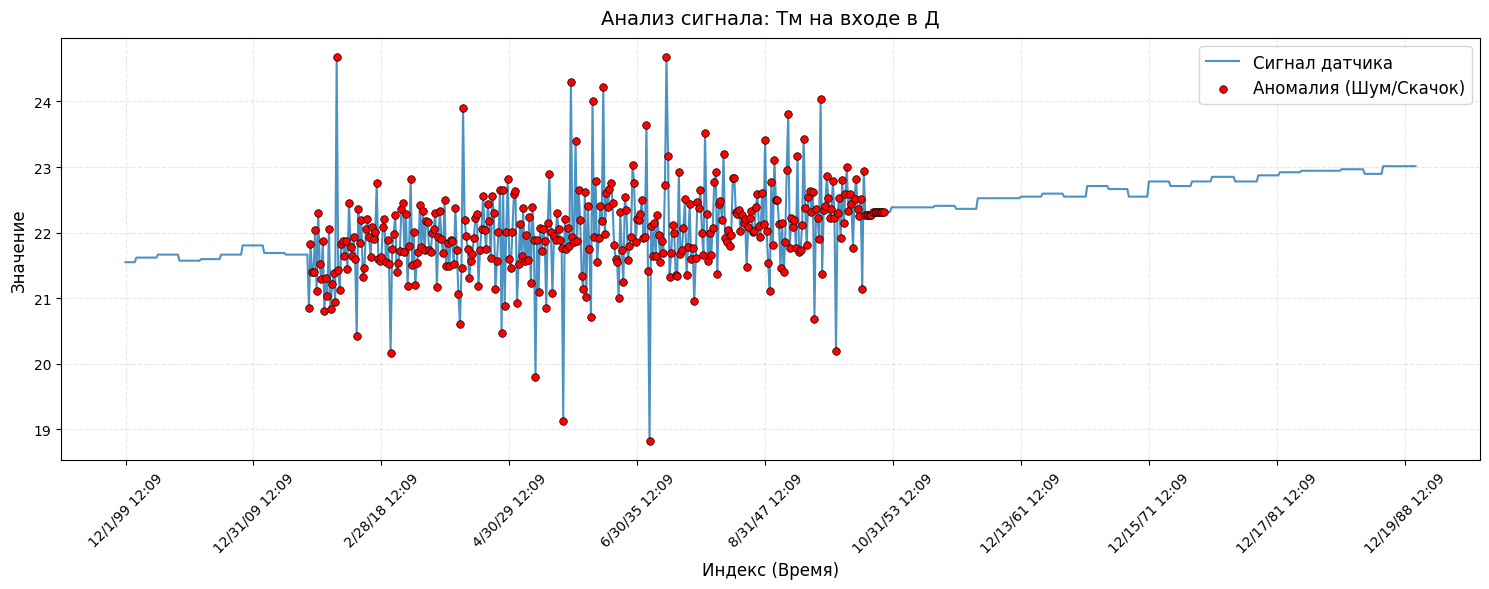

In [335]:
def plot_anomalies_from_df(df, time_col='TimeStamp', label_col='0 - Bad, 1 - Good', 
                           start_idx=None, end_idx=None):
    """
    Строит график сигнала и выделяет красным цветом точки аномалий.
    """
    # Определяем название колонки с самим датчиком (та, которая не время и не метка)
    sensor_col = [col for col in df.columns if col not in [time_col, label_col]][0]
    
    # Делаем срез данных, если запрошен зум
    plot_df = df.iloc[start_idx:end_idx].copy()
    
    # Разделяем данные на норму и аномалии
    # Напоминание: в нашем формате 0 - это аномалия (Bad), 1 - это норма (Good)
    anomalies = plot_df[plot_df[label_col] == 0]
    
    plt.figure(figsize=(15, 6))
    
    # 1. Рисуем основной сигнал (синяя линия)
    # Используем индекс для оси X, чтобы избежать проблем с форматами времени в matplotlib
    plt.plot(plot_df.index, plot_df[sensor_col], label='Сигнал датчика', color='#1f77b4', linewidth=1.5, alpha=0.8)
    
    # 2. Накладываем точки аномалий (красные точки)
    # zorder=5 гарантирует, что точки будут нарисованы ПОВЕРХ линии
    plt.scatter(anomalies.index, anomalies[sensor_col], color='red', label='Аномалия (Шум/Скачок)', 
                s=30, zorder=5, edgecolors='black', linewidths=0.5)
    
    # Настройка внешнего вида
    plt.title(f'Анализ сигнала: {sensor_col}', fontsize=14, pad=10)
    plt.xlabel('Индекс (Время)', fontsize=12)
    plt.ylabel('Значение', fontsize=12)
    plt.legend(fontsize=12, loc='upper right')
    plt.grid(True, alpha=0.3, linestyle='--')
    
    # Опционально: настраиваем метки оси X так, чтобы они показывали реальное время (через каждые N точек)
    num_ticks = 10
    step = max(1, len(plot_df) // num_ticks)
    tick_indices = plot_df.index[::step]
    tick_labels = plot_df[time_col].iloc[::step]
    plt.xticks(tick_indices, tick_labels, rotation=45)
    
    plt.tight_layout()
    plt.show()

def plot_anomalies_from_csv(csv_path, time_col='TimeStamp', label_col='0 - Bad, 1 - Good', 
                            start_idx=None, end_idx=None):
    """
    Удобная обертка: читает файл отчета инференса и сразу рисует график.
    """
    print(f"Загрузка файла: {csv_path}...")
    # Читаем с защитой от BOM-символа
    df = pd.read_csv(csv_path, encoding='utf-8-sig')
    df.columns = df.columns.str.strip() # Очистка невидимых пробелов
    
    if label_col not in df.columns:
        print(f"ОШИБКА: Колонка разметки '{label_col}' не найдена в файле.")
        return
        
    plot_anomalies_from_df(df, time_col, label_col, start_idx, end_idx)


plot_anomalies_from_csv("inference_reports/Тм_на_входе_в_Д_report.csv")

In [336]:
compute_metrics(labels_true=labels_true_val, labels_pred=labels_pred)

{'accuracy': 0.9845, 'precision': 0.9652, 'recall': 1.0, 'f1': 0.9823}

In [337]:
df_test_raw = pd.read_csv("data/3.csv", encoding="1251", sep=";")
df_test_raw.columns = df_test_raw.columns.str.strip()

def create_corrupted_test_bench(df, time_column='ТР', corruption_ratio=0.3):
    """
    Создает копию данных с внедренными аномалиями.
    Исправлено: добавлена копия массива для обхода ошибки read-only.
    """
    df_corrupted = df.copy()
    # Создаем матрицу меток (изначально всё 1.0)
    df_labels = pd.DataFrame(np.ones(df.shape), columns=df.columns, index=df.index)
    
    sensor_columns = [col for col in df.columns if col != time_column]
    print(len(sensor_columns))
    
    # Случайный выбор колонок для порчи
    n_to_corrupt = int(len(sensor_columns) * corruption_ratio)
    target_cols = np.random.choice(sensor_columns, n_to_corrupt, replace=False)
    
    print(f"Будут зашумлены следующие каналы: {list(target_cols)}")

    for col in sensor_columns:
        # ПРЕОБРАЗОВАНИЕ В ЧИСЛА
        df_corrupted[col] = pd.to_numeric(df_corrupted[col], errors='coerce').fillna(0).astype(float)
        
        if col in target_cols:
            # .copy() — ГЛАВНОЕ ИСПРАВЛЕНИЕ: создаем массив, доступный для записи
            signal = df_corrupted[col].values.copy()
            labels = df_labels[col].values.copy()
            
            base_level = np.abs(np.median(signal)) + 0.1
            n_pts = len(signal)
            
            # Внедряем одиночные скачки (Spikes)
            n_spikes = np.random.randint(10, 50)
            if n_pts > 10:
                spike_indices = np.random.choice(n_pts, n_spikes, replace=False)
                for idx in spike_indices:
                    magnitude = base_level * np.random.uniform(0.05, 0.15)
                    # Теперь запись разрешена
                    signal[idx] += np.random.choice([-1, 1]) * magnitude
                    labels[idx] = 0
            
            # Внедряем блоки дребезга (Noise Blocks)
            for _ in range(np.random.randint(2, 4)):
                block_len = np.random.randint(10, 30)
                if n_pts > block_len:
                    start_idx = np.random.randint(0, n_pts - block_len)
                    noise = np.random.normal(0, base_level * 0.05, block_len)
                    signal[start_idx : start_idx + block_len] += noise
                    labels[start_idx : start_idx + block_len] = 0
                
            # Возвращаем измененные данные обратно в DataFrame
            df_corrupted[col] = signal
            df_labels[col] = labels
        else:
            df_labels[col] = 1.0

    return df_corrupted, df_labels

# Генерируем данные
df_test, df_labels = create_corrupted_test_bench(df_test_raw, corruption_ratio=0.2)
print(df_test.shape, df_labels.shape)


40
Будут зашумлены следующие каналы: [np.str_('Т м. на выходе из СТ'), np.str_('Т газа за ГГ (ср.)'), np.str_('Т за ГГ на запуске (т.2)'), np.str_('Обороты КВД 1'), np.str_('Т за СТ (т.11)'), np.str_('Т за ГГ на запуске (т.1)'), np.str_('Т м. на входе Д'), np.str_('Т ТГ перед ДГ')]
(14896, 41) (14896, 41)


In [338]:
def run_final_validation(df_test, df_labels, model_path="saved_models/UNIVERSAL_model.pkl", window_size=15):
    """
    Проводит полный инференс по всем датчикам и сравнивает с истинными метками.
    Добавлена строгая проверка типов данных.
    """
    if not os.path.exists(model_path):
        print(f"❌ Ошибка: Модель {model_path} не найдена!")
        return None
    
    model = joblib.load(model_path)
    # Берем только те колонки, которые есть и в тесте, и в метках, и это не TimeStamp
    sensor_columns = [col for col in df_test.columns if col in df_labels.columns and col != 'ТР']
    
    results = []

    print(f"🚀 Начинаем финальную валидацию по {len(sensor_columns)} каналам...")

    for col in sensor_columns:
        # --- ГЛАВНЫЙ ФИКС: Принудительное преобразование в числа ---
        # errors='coerce' превратит строки в NaN, которые мы заполним нулями
        signal = pd.to_numeric(df_test[col], errors='coerce').fillna(0).astype(float)
        
        # 2. Извлечение признаков
        features = extract_features(signal, window_size) 
        X = features.values
        
        # 3. Предсказание
        y_pred = model.predict(X).astype(int)
        
        # Преобразуем и метки тоже, на всякий случай
        y_true = pd.to_numeric(df_labels[col], errors='coerce').fillna(1).astype(int).values
        
        # 4. Расчет метрик (pos_label=0 для поиска аномалий)
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, pos_label=0, zero_division=1)
        rec = recall_score(y_true, y_pred, pos_label=0, zero_division=1)
        f1 = f1_score(y_true, y_pred, pos_label=0, zero_division=1)
        
        is_corrupted = 1 if 0 in y_true else 0
        
        results.append({
            'Sensor': col,
            'Is_Corrupted': is_corrupted,
            'Accuracy': acc,
            'Precision (Anomaly)': prec,
            'Recall (Anomaly)': rec,
            'F1-Score': f1
        })

    summary_df = pd.DataFrame(results)
    corrupted_only = summary_df[summary_df['Is_Corrupted'] == 1]
    
    print("\n" + "="*60)
    print("ИТОГИ ТЕСТИРОВАНИЯ УНИВЕРСАЛЬНОЙ МОДЕЛИ")
    print("-"*60)
    print(f"Всего датчиков проверено:    {len(summary_df)}")
    print(f"Из них было зашумлено:       {len(corrupted_only)}")
    print("-"*60)
    if len(corrupted_only) > 0:
        print(f"Средний F1-Score (по шуму):  {corrupted_only['F1-Score'].mean():.4f}")
        print(f"Средний Precision (по шуму): {corrupted_only['Precision (Anomaly)'].mean():.4f}")
        print(f"Средний Recall (по шуму):    {corrupted_only['Recall (Anomaly)'].mean():.4f}")
    else:
        print("Внимание: Зашумленные датчики не найдены в выборке!")
    print(f"Средний Accuracy (общая):    {summary_df['Accuracy'].mean():.4f}")
    print("="*60)
    
    return summary_df

val_results = run_final_validation(df_test, df_labels)
# if val_results is not None:
#     print("\nДатчики с худшим результатом (проверьте их):")
    # print(val_results.sort_values(by='F1-Score'))

🚀 Начинаем финальную валидацию по 40 каналам...

ИТОГИ ТЕСТИРОВАНИЯ УНИВЕРСАЛЬНОЙ МОДЕЛИ
------------------------------------------------------------
Всего датчиков проверено:    40
Из них было зашумлено:       8
------------------------------------------------------------
Средний F1-Score (по шуму):  0.1988
Средний Precision (по шуму): 0.1119
Средний Recall (по шуму):    0.9898
Средний Accuracy (общая):    0.9839
